In [1]:
import re
from bs4 import BeautifulSoup as bs
import pandas
import numpy as np
import requests
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import seaborn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer 
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score
from nltk.stem import WordNetLemmatizer
import wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [38]:
source = []
title = []
author = []
date = []
target = [] 

In [39]:
def web_scraping(page_nub):
    global source
    global title
    global author
    global date
    global target
    
    s = []
    t = []
    s_author = []
    s_date = []
    ta = []
    
   
    url = "https://www.politifact.com/factchecks/list/?page="+str(page_nub)
    respons = requests.get(url)
    soup = bs(respons.content, "html.parser")
    #source
    statement__meta = soup.find_all("div", attrs = {"class","m-statement__meta" })
    # title
    statement__quote = soup.find_all("div", attrs = {"class", "m-statement__quote"} )
    #author
    statement__footer = soup.find_all("footer", attrs = {"class","m-statement__footer" })
    # getting target
    statement__meter = soup.find_all("div", attrs = {"class", "m-statement__meter"})
    
    for i in statement__meta:
        app_name = i.find("a", attrs = { "a", "m-statement__name"}).get("title")
        s.append(app_name)
        #print(s[1])
    for i in range(len(statement__quote)):
        t.append(statement__quote[i].text.strip())
    for i in range(len(statement__footer)):
        author_date =statement__footer[i].text.strip()
        split_author_date = author_date.split("•")
        author_name = split_author_date [0]
        author_date = split_author_date[1]
        s_author.append(author_name)
        s_date.append(author_date)    
    for i in statement__meter:
        link = i.find("div", attrs = {"class","c-image"}).find("img").get("alt")
        ta.append(link)
    
    source = source + s
    title = title + t
    author = author + s_author
    date = date + s_date
    target = target + ta

In [40]:
n = 708
for i in range(1,n):
    web_scraping(i)

In [41]:
data = pandas.DataFrame({"author": author,"title": title , "source": source ,"date":date,"target":target})

In [42]:
data.to_csv("web_scraping.csv")

In [3]:
data = pandas.read_csv("C:\\Users\\Hans\\Documents\\Code\\projects\\Real_or_Fake_News_Classifier\\web_scraping.csv")

In [8]:

import nltk
nltk.download('wordnet')
import re
from nltk.stem import WordNetLemmatizer

# Initialize
lem = WordNetLemmatizer()

positive_word = []
negative_word = []

# Load sentiment lexicons
with open(r"C:\Users\Hans\Documents\Code\projects\Real_or_Fake_News_Classifier\negative-words.txt", "r") as neg:
    negativewords = set(neg.read().split("\n"))

with open(r"C:\Users\Hans\Documents\Code\projects\Real_or_Fake_News_Classifier\positive-words.txt", "r") as pos:
    positive = set(pos.read().split("\n"))

# Process titles
for i in range(len(data)):
    perfect_sen = []

    # Clean text
    sent = re.sub(r"[^A-Za-z]+", " ", str(data.loc[i, "title"])).lower()

    # Tokenization WITHOUT nltk.tokenize
    sentence = sent.split()

    for word in sentence:
        if len(word) >= 3:
            lemma = lem.lemmatize(word)
            perfect_sen.append(lemma)

            if lemma in positive:
                positive_word.append(lemma)

            if lemma in negativewords:
                negative_word.append(lemma)

    # Update dataframe safely
    data.loc[i, "title"] = " ".join(perfect_sen)


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Hans\AppData\Roaming\nltk_data...


In [9]:
positive_word = " ".join(positive_word)
negative_word = " ".join(negative_word)

In [10]:
data.to_csv("all_ok.csv")

In [11]:
print(len(positive_word))
print(len(negative_word))

59448
78248


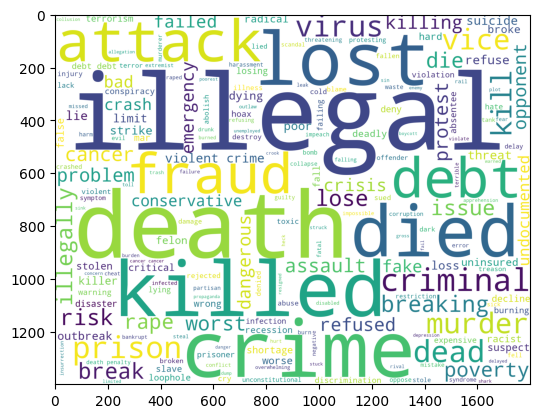

In [12]:
wordcloud_ip = WordCloud(background_color='White',width=1800,height=1400).generate(negative_word)
plt.imshow(wordcloud_ip)

In [13]:
data.shape

(21210, 6)

In [14]:
data.head()

,Unnamed: 0,author,title,source,date,target
0,0,By Jeff Cercone,brown university student mustapha karbouch wa ...,Social Media,"December 19, 2025",false
1,1,By Maria Briceño,image from jeffrey epstein archive show presid...,X posts,"December 19, 2025",pants-fire
2,2,By Maria Briceño,image show rob reiner tweeted that would stop ...,Laura Loomer,"December 17, 2025",false
3,3,By Jill Terreri Ramos,gov kathy hochul ha raised tax,Elise Stefanik,"December 11, 2025",half-true
4,4,By Louis Jacobson,the ha received promise investment totaling tr...,Donald Trump,"December 9, 2025",false


<Axes: xlabel='count', ylabel='target'>

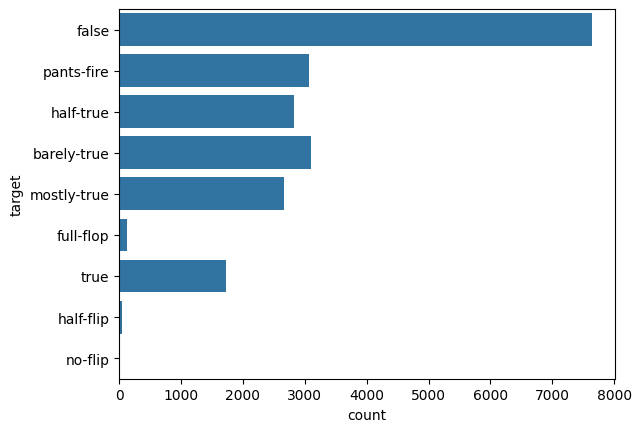

In [15]:
seaborn.countplot(data["target"])

In [16]:
data['target'].value_counts()

target
false          7633
barely-true    3093
pants-fire     3074
half-true      2833
mostly-true    2667
true           1719
full-flop       124
half-flip        52
no-flip          15
Name: count, dtype: int64

In [17]:
data["target"].replace(to_replace=["half-true", "barely-true", "mostly-true", "true"], value = 1, inplace = True)

C:\Users\Hans\AppData\Local\Temp\ipykernel_9976\705675706.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["target"].replace(to_replace=["half-true", "barely-true", "mostly-true", "true"], value = 1, inplace = True)


In [18]:
data["target"].replace(to_replace =["false", "full-flop", "half-flip", "pants-fire"], value = 0 ,inplace = True)

In [19]:
data["target"].value_counts()

target
0          10883
1          10312
no-flip       15
Name: count, dtype: int64

In [20]:
data.drop(data[data["target"] == "no-flip"].index, inplace = True, axis=0)

<Axes: ylabel='count'>

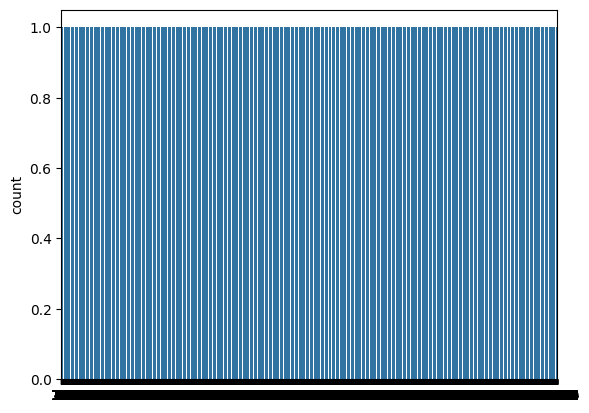

In [21]:
seaborn.countplot(data['target'])

In [22]:
data.columns

Index(['Unnamed: 0', 'author', 'title', 'source', 'date', 'target'], dtype='object')

In [23]:
data.describe()

,Unnamed: 0
count,21195.000000
mean,10600.850861
std,6122.559639
min,0.000000
25%,5298.500000
50%,10598.000000
75%,15902.500000
max,21209.000000


In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21195 entries, 0 to 21209
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  21195 non-null  int64 
 1   author      21191 non-null  object
 2   title       21195 non-null  object
 3   source      21195 non-null  object
 4   date        21195 non-null  object
 5   target      21195 non-null  object
dtypes: int64(1), object(5)
memory usage: 1.1+ MB


In [25]:
x = data.drop(labels=['author', 'source', 'date', 'target'], axis = 1)
y = data['target']
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.33)

In [26]:
x_train.shape,x_test.shape

((14200, 2), (6995, 2))

In [27]:
y_train = y_train.astype("int64")
y_test = y_test.astype("int64")

In [28]:
tfidf = TfidfVectorizer()
tfidf.fit(x_train["title"])
tfidf_x_train = tfidf.transform(x_train['title'])
tfidf_x_test = tfidf.transform(x_test['title'])

In [29]:
tfidf_x_train.shape,tfidf_x_test.shape

((14200, 13778), (6995, 13778))

In [30]:
classifier = PassiveAggressiveClassifier()
classifier.fit(tfidf_x_train,y_train)

PassiveAggressiveClassifier()

In [31]:
pred_train = classifier.predict(tfidf_x_train)
pred_test = classifier.predict(tfidf_x_test)

In [32]:
accuracy_score(y_train, pred_train)

0.977887323943662

<Axes: >

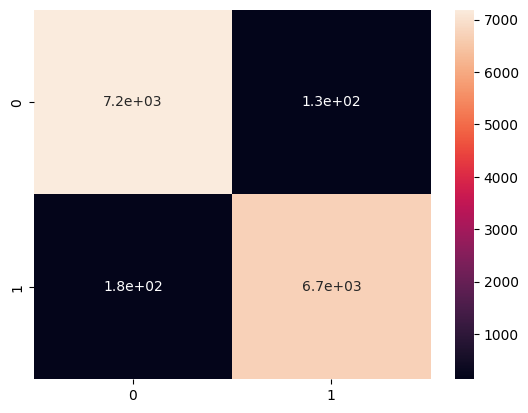

In [33]:
confusion_train = confusion_matrix(pred_train, y_train)
seaborn.heatmap(confusion_train, annot=True)

In [34]:
accuracy_score(y_test, pred_test,)

0.6566118656182988

<Axes: >

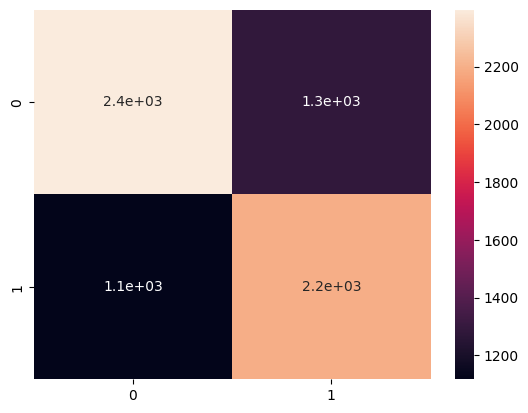

In [35]:
confusion_test = confusion_matrix(pred_test, y_test)
seaborn.heatmap(confusion_test, annot=True)

In [36]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=3073, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)
lr.fit(tfidf_x_train, y_train)

c:\Users\Hans\Documents\Code\projects\Real_or_Fake_News_Classifier\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='auto', random_state=3073)

In [37]:
lrpred_train = lr.predict(tfidf_x_train)
lrpred_test = lr.predict(tfidf_x_test)

In [38]:
accuracy_score(y_train, lrpred_train)

0.8314084507042253

<Axes: >

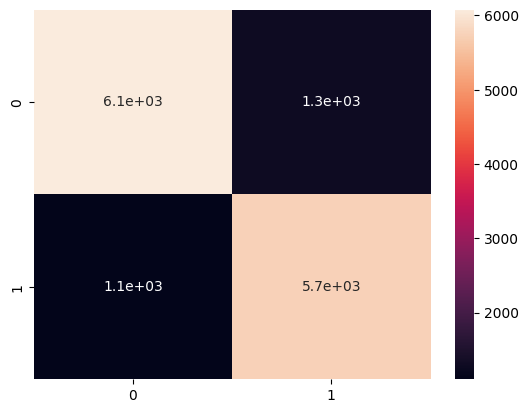

In [39]:
lrconfusion_train = confusion_matrix(y_train, lrpred_train)
seaborn.heatmap(lrconfusion_train, annot=True)

In [40]:
accuracy_score(y_test, lrpred_test,)

0.7421015010721944

<Axes: >

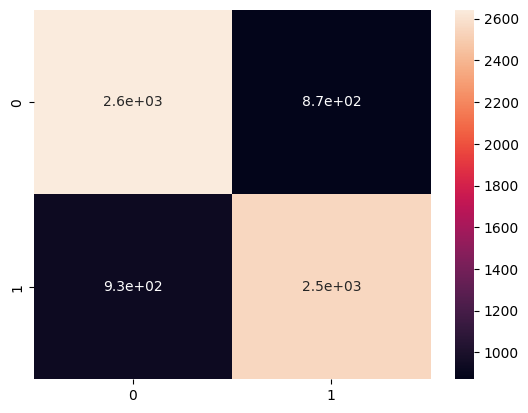

In [41]:
confusion_test = confusion_matrix(y_test, lrpred_test,)
seaborn.heatmap(confusion_test, annot=True)

In [42]:
import pickle
pickle.dump(lr, open('pred.pkl','wb'))
pickle.dump(tfidf,open("tfidf.pkl","wb"))